In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import tensorflow as tf
from src.NN_Utils import TimeSeriesRandomSearch, make_build_model
from src.Utils import plot_performance_analysis
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

<h2>Lectura y Tratamiento de Datos</h2>

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

**Validación por Retención (Tratamiento como Serie Temporal)**

In [3]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda de Mejores Modelos</h2>

In [4]:
input_dim = x_train.shape[1]
num_volts = len([c for c in y_train.columns if c.startswith('V')])
normalizer_layer = tf.keras.layers.Normalization(axis=-1)
normalizer_layer.adapt(x_train.values)
builder_function = make_build_model(input_dim, num_volts, normalizer_layer)

y_train_qgen = y_train[['QGEN7']]
y_train_perd = y_train[['PERD']]
y_train_volt = y_train.drop(columns=['QGEN7', 'PERD'])

tuner = TimeSeriesRandomSearch(builder_function, objective='val_loss', max_trials=10, overwrite=True, project_name='nn_random_search', seed=42)

In [5]:
tuner.search(
    x_train,
    y={
        'out_volt': y_train_volt,
        'out_perd': y_train_perd,
        'out_qgen7': y_train_qgen,
    },
    epochs=10,
    batch_size=32
)

Trial 10 Complete [00h 03m 28s]
val_loss: 0.012359170056879521

Best val_loss So Far: 0.009347542282193899
Total elapsed time: 00h 23m 32s


In [6]:
best_random_model = tuner.oracle.get_best_trials(1)[0]
for metric_name in best_random_model.metrics.metrics.keys():
    val = best_random_model.metrics.get_best_value(metric_name)
    print(f"{metric_name}: {val:.5f}")

val_loss: 0.00935
val_out_perd_loss: 0.00053
val_out_perd_mae: 0.01545
val_out_perd_mape: 8.69538
val_out_perd_r2_score: 0.97343
val_out_qgen7_loss: 0.00663
val_out_qgen7_mae: 0.04029
val_out_qgen7_mape: 6.66635
val_out_qgen7_r2_score: 0.82841
val_out_volt_loss: 0.00165
val_out_volt_mae: 0.02706
val_out_volt_mape: 425.58631
val_out_volt_r2_score: 0.93536


<h2>Evaluación del Mejor Modelo</h2>

In [7]:
best_random_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = builder_function(best_random_hp)
normalizer_qgen = MinMaxScaler(feature_range=(0, 1))
normalizer_volts = MinMaxScaler(feature_range=(0, 1))
normalizer_perd = MinMaxScaler(feature_range=(0, 1))
y_train_qgen_norm = normalizer_qgen.fit_transform(y_train_qgen)
y_train_perd_norm = normalizer_perd.fit_transform(y_train_perd)
y_train_volt_norm = normalizer_volts.fit_transform(y_train_volt)

In [8]:
results = best_model.fit(
    x_train,
    {
        'out_qgen7': y_train_qgen_norm,
        'out_volt': y_train_volt_norm,
        'out_perd': y_train_perd_norm
    },
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/20
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1723 - out_perd_loss: 0.0031 - out_perd_mae: 0.0374 - out_perd_mape: 195.5220 - out_perd_r2_score: 0.5891 - out_qgen7_loss: 0.0334 - out_qgen7_mae: 0.1358 - out_qgen7_mape: 11192.0762 - out_qgen7_r2_score: 0.1347 - out_volt_loss: 0.1327 - out_volt_mae: 0.2591 - out_volt_mape: 8776.3457 - out_volt_r2_score: -7.5376 - val_loss: 0.0325 - val_out_perd_loss: 5.9282e-04 - val_out_perd_mae: 0.0195 - val_out_perd_mape: 13.1589 - val_out_perd_r2_score: 0.9225 - val_out_qgen7_loss: 0.0126 - val_out_qgen7_mae: 0.0831 - val_out_qgen7_mape: 13.0590 - val_out_qgen7_r2_score: 0.6743 - val_out_volt_loss: 0.0187 - val_out_volt_mae: 0.1080 - val_out_volt_mape: 20.4381 - val_out_volt_r2_score: -0.1895
Epoch 2/20
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0334 - out_perd_loss: 4.3660e-04 - out_perd_mae: 0.0157 - out_perd_mape: 50.9780 - out_perd_r2_score: 0.9424 - out_qgen7_loss: 0.0135 - out_qgen7_mae: 0.0790 - out_qgen7_mape: 1313

In [9]:
predictions = best_model.predict(x_test)
pred_volts_norm = predictions[0]
pred_perd_norm = predictions[1]
pred_qgen_norm = predictions[2]
y_pred_volts = normalizer_volts.inverse_transform(pred_volts_norm)
y_pred_perd = normalizer_perd.inverse_transform(pred_perd_norm)
y_pred_qgen = normalizer_qgen.inverse_transform(pred_qgen_norm)
y_pred = pd.DataFrame(np.hstack([y_pred_volts, y_pred_perd, y_pred_qgen]), columns=y_test.columns, index=y_test.index)

656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step


In [10]:
evaluate_MAE = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
evaluate_MAPE = mean_absolute_percentage_error(y_test, y_pred, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
evaluate_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, y_pred + 1.0, multioutput='raw_values')
evaluate_R2 = r2_score(y_test, y_pred, multioutput='raw_values')

In [11]:
# RESULTADOS CON MAPE DESPLAZADO
evaluate_data_score_shifted = np.vstack([evaluate_MAE, evaluate_MAPE_shifted, evaluate_R2])
evaluations_shifted = pd.DataFrame(evaluate_data_score_shifted, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001710,0.001713,0.001716,0.001716,0.001716,0.001717,0.001717,0.001717,0.001717,0.001717,0.001717,0.001044,0.001044,0.349683,0.008508
MAPE,0.000867,0.000869,0.000870,0.000870,0.000871,0.000871,0.000871,0.000871,0.000871,0.000871,0.000871,0.000527,0.000527,0.044661,0.008061
R2,0.973708,0.973946,0.974068,0.974094,0.974102,0.974126,0.974036,0.974081,0.974085,0.974105,0.974113,0.987018,0.987029,0.968089,0.848839


In [12]:
# RESULTADOS SIN DESPLAZADO
evaluate_data_score = np.vstack([evaluate_MAE, evaluate_MAPE, evaluate_R2])
evaluations = pd.DataFrame(evaluate_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001710,0.001713,0.001716,0.001716,0.001716,0.001717,0.001717,0.001717,0.001717,0.001717,0.001717,0.001044,0.001044,0.349683,8.507602e-03
MAPE,0.001759,0.001763,0.001766,0.001767,0.001767,0.001768,0.001768,0.001768,0.001768,0.001767,0.001767,0.001063,0.001063,0.054579,1.470640e+13
R2,0.973708,0.973946,0.974068,0.974094,0.974102,0.974126,0.974036,0.974081,0.974085,0.974105,0.974113,0.987018,0.987029,0.968089,8.488393e-01


In [13]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE DESPLAZADO)
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes (Desplazados)': evaluations_shifted[volts_columns].mean(axis=1),
    'Pérdidas (Desplazada)': evaluations_shifted['PERD'],
    'Potencia Reactiva (Desplazada)': evaluations_shifted['QGEN7']
})

,Voltajes (Desplazados),Pérdidas (Desplazada),Potencia Reactiva (Desplazada)
MAE,0.001612,0.349683,0.008508
MAPE,0.000817,0.044661,0.008061
R2,0.976039,0.968089,0.848839


In [14]:
# EVALUACIÓN FINAL CON MEDIA DE VOLTAJES (MAPE SIN DESPLAZAMIENTO)
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.001612,0.349683,8.507602e-03
MAPE,0.001658,0.054579,1.470640e+13
R2,0.976039,0.968089,8.488393e-01


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [15]:
best_model.save('../models/MO_NeuralNetwork.keras')

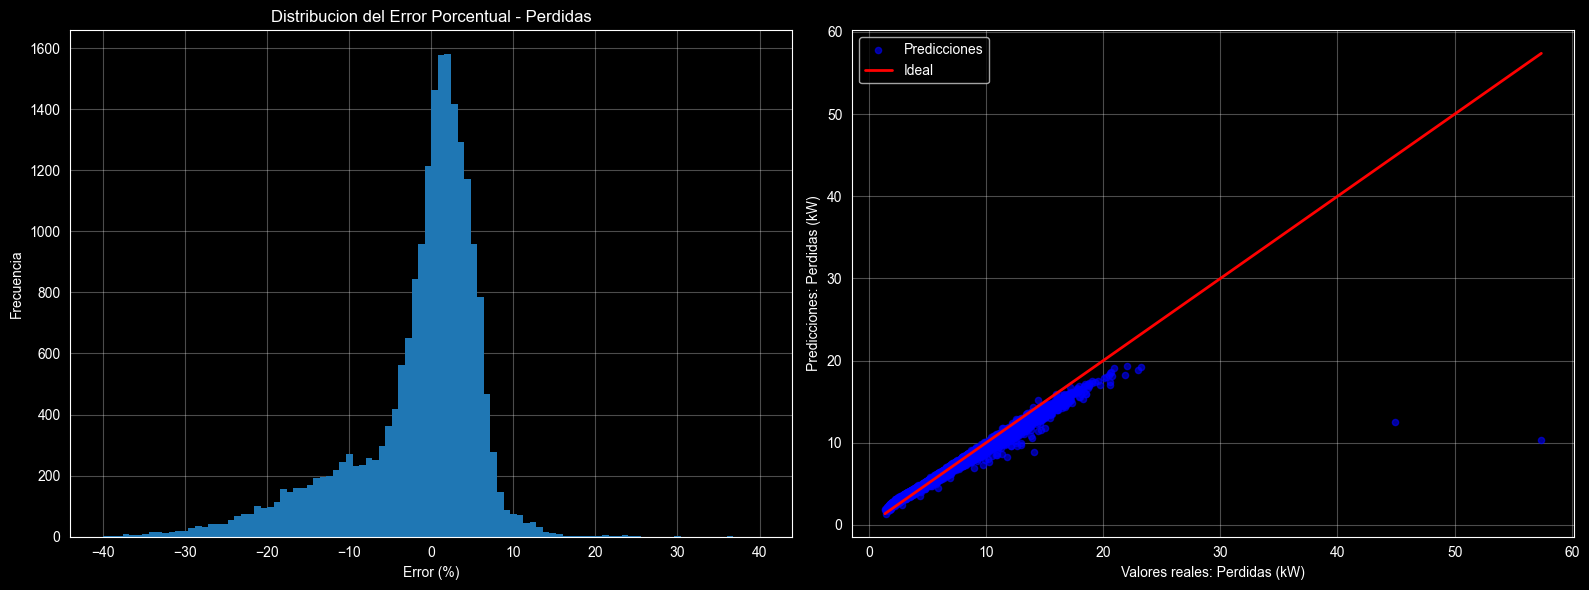

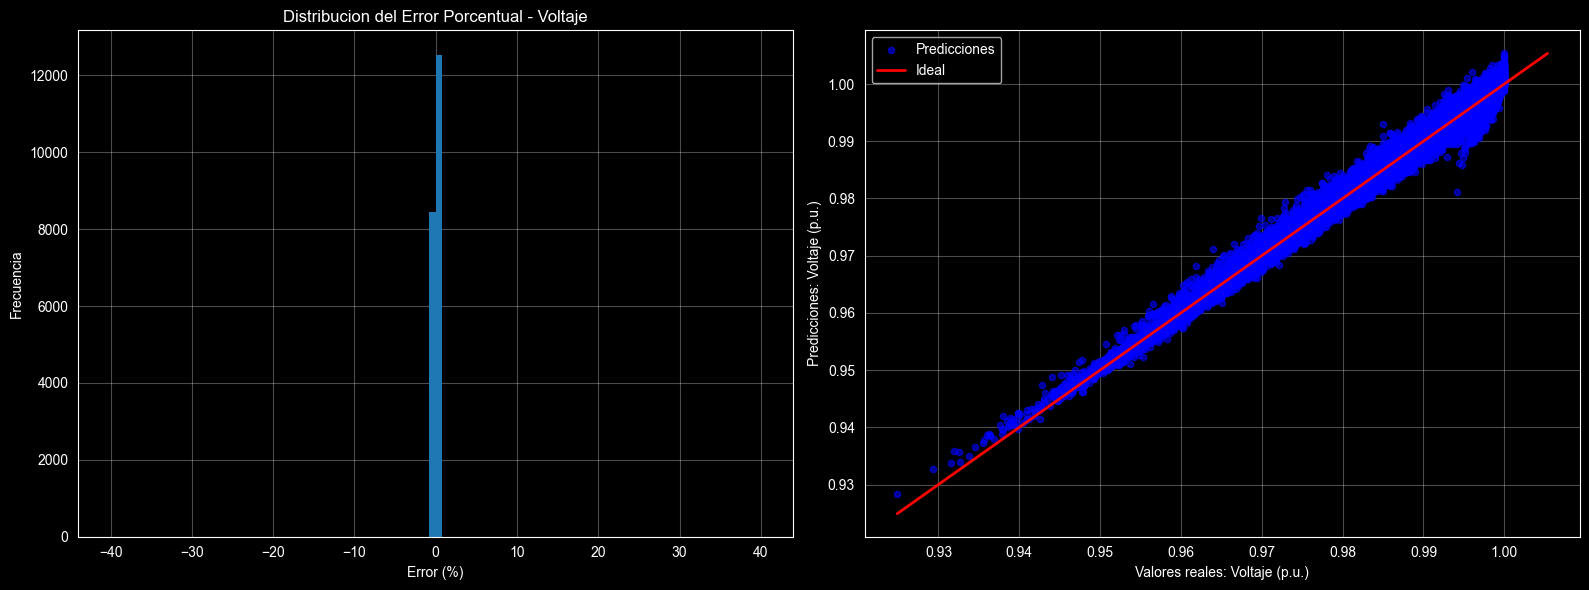

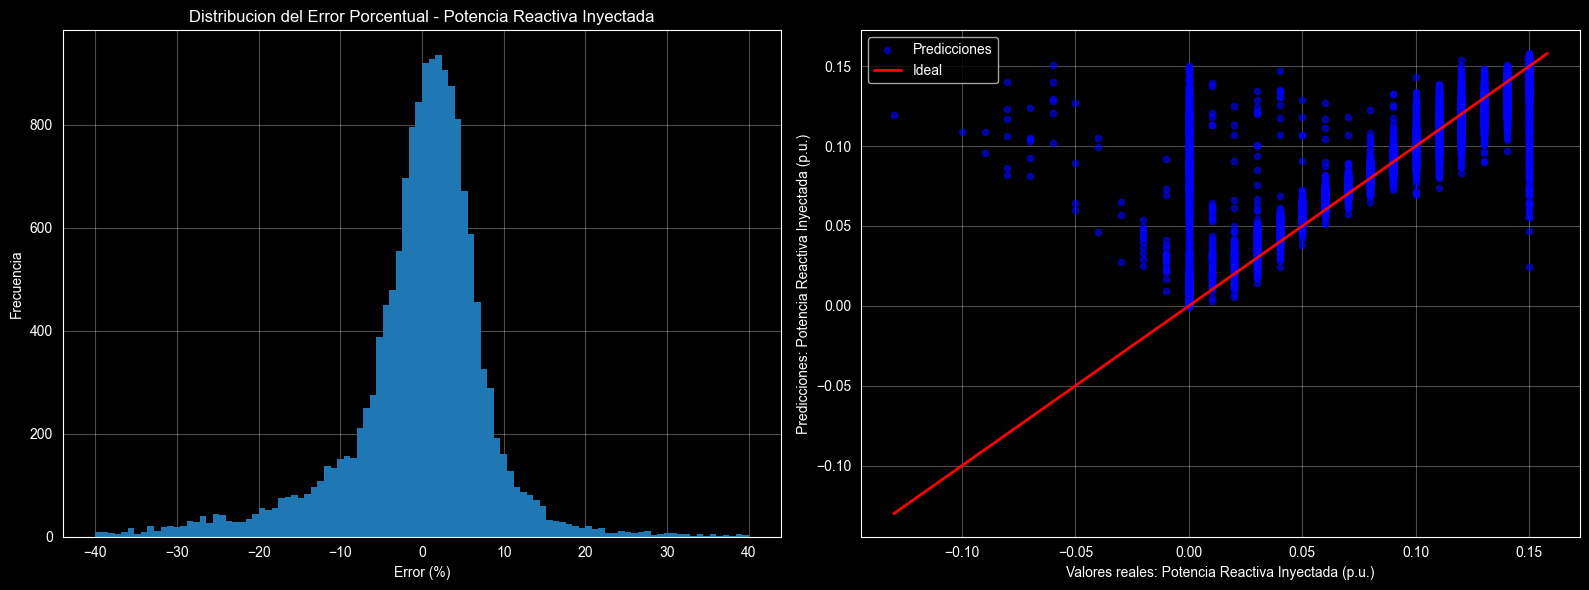

In [16]:
plot_performance_analysis(
    y_test['PERD'],
    y_pred.iloc[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    y_pred.loc[:, 'V13'],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    y_pred.iloc[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_QGen.png'
)